In [ ]:
!pip install ipympl ultralytics

  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.3/516.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 870.5/870.5 kB 42.4 MB/s eta 0:00:00
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)


In [ ]:
import zipfile
import os

# Define the paths
zip_path = "/content/Annotation Study.zip"
extract_path = "/content/"

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Unzipped {zip_path} to {extract_path}")


Unzipped /content/Annotation Study.zip to /content/


In [ ]:
%matplotlib widget

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import json
import os
import time
import glob
import torch
import cv2
#from ultralytics import SAM


In [ ]:
from transformers import SamProcessor
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

In [ ]:
class BboxPromptDemo:
    def __init__(self, directory_path, model):
        self.directory_path = directory_path
        self.image_files = sorted(glob.glob(os.path.join(directory_path, '*.jpg')))
        self.current_image_index = 0
        self.image = None
        self.fig, self.ax = None, None
        self.bbox = None
        self.bboxes = {}
        self.clear_count = 0
        self.timestamps = {
            "first_click": None,
            "save_clicked": None
        }
        self.currently_selecting = False
        self.model = model
        self.load_image()

    def load_image(self):
        """Load an image from a file and display it."""
        if self.image_files:
            image_path = self.image_files[self.current_image_index]
            self.image = plt.imread(image_path)
            self.show_image()
        else:
            print("No images found in the directory.")

    def show_image(self, mask_array=None):
        """Show the image with interactive bounding box drawing capabilities and optional mask overlay."""
        if self.image is not None:
            clear_output(wait=True)

            # Create the figure and axis for displaying the image
            self.fig, self.ax = plt.subplots(figsize=(5, 5))

            # Display the original image
            self.ax.imshow(self.image)
            self.ax.axis('off')

            # Overlay the mask if provided
            if mask_array is not None:
                self.ax.imshow(mask_array, cmap='jet', alpha=0.5)  # Adjust alpha to control mask transparency

            # Set the title with the filename
            filename = os.path.basename(self.image_files[self.current_image_index])
            self.ax.set_title(filename, fontsize=15)

            # Set up the interactive bounding box events
            self.fig.canvas.mpl_connect('button_press_event', self.on_press)
            self.fig.canvas.mpl_connect('button_release_event', self.on_release)
            self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)

            # Add buttons or other interactive elements if necessary
            self.add_buttons()
        else:
            print("No image loaded.")


    def show_image2(self):
        """Show the image with interactive bounding box drawing capabilities."""
        if self.image is not None:
            clear_output(wait=True)


            self.fig, self.ax = plt.subplots(figsize=(5, 5))


            self.ax.imshow(self.image)
            self.ax.axis('off')


            filename = os.path.basename(self.image_files[self.current_image_index])
            self.ax.set_title(filename, fontsize=15)

            self.fig.canvas.mpl_connect('button_press_event', self.on_press)
            self.fig.canvas.mpl_connect('button_release_event', self.on_release)
            self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
            self.add_buttons()
        else:
            print("No image loaded.")

    def on_press(self, event):
        """Handle mouse button press events."""
        if event.inaxes != self.ax:
            return

        self.x0, self.y0 = event.xdata, event.ydata
        self.currently_selecting = True
        self.timestamps ={
            "first_click": time.time(),
            "save_click": None
        }

        self.rect = plt.Rectangle(
            (self.x0, self.y0),
            1, 1, linestyle="--",
            edgecolor="crimson", fill=False
        )
        self.ax.add_patch(self.rect)

    def on_release(self, event):
        """Handle mouse button release events."""
        if not self.currently_selecting:
            return

        self.x1, self.y1 = event.xdata, event.ydata
        self.currently_selecting = False
        #self.timestamps["save_clicked"] = time.time()

        # Finalize the bounding box dimensions
        self.rect.set_width(self.x1 - self.x0)
        self.rect.set_height(self.y1 - self.y0)
        self.rect.set_visible(True)
        self.fig.canvas.draw_idle()

        # Save the bounding box
        self.bbox = [self.x0, self.y0, self.x1, self.y1]
        print(f"Bounding box saved: {self.bbox}")

        # Immediately run SAM inference
        filename = os.path.basename(self.image_files[self.current_image_index])
        print(f"Running SAM inference for {filename} with bounding box {self.bbox}...")
        self.run_sam_inference(filename, self.bbox)

        # Optionally, clear the bounding box after inference (optional)
        #self.bbox = None


    def on_motion(self, event):
        """Handle mouse motion events."""
        if not self.currently_selecting:
            return

        self.x1, self.y1 = event.xdata, event.ydata


        self.rect.set_width(self.x1 - self.x0)
        self.rect.set_height(self.y1 - self.y0)
        self.fig.canvas.draw_idle()

    def add_buttons(self):
        """Add navigation and action buttons below the figure."""
        previous_button = widgets.Button(description="Previous")
        next_button = widgets.Button(description="Next")
        save_button = widgets.Button(description="Save")
        clear_button = widgets.Button(description="Clear")
        end_button = widgets.Button(description="End")
        previous_button.on_click(self.on_previous_clicked)
        next_button.on_click(self.on_next_clicked)
        save_button.on_click(self.on_save_clicked)
        clear_button.on_click(self.on_clear_clicked)
        end_button.on_click(self.on_end_clicked)
        button_box = widgets.HBox([previous_button, next_button, save_button, clear_button, end_button])
        display(button_box)

    def on_previous_clicked(self, b):
        """Go to the previous image."""
        if self.current_image_index > 0:
            self.current_image_index -= 1
            self.load_image()

    def on_next_clicked(self, b):
        """Go to the next image."""
        self.clear_count = 0
        if self.current_image_index < len(self.image_files) - 1:
            self.current_image_index += 1
            self.load_image()

    def on_save_clicked(self, b):
        """Handle Save button click: save bounding box data to JSON."""
        self.timestamps["save_click"] = time.time()
        self.annotation_time = self.timestamps["save_click"] - self.timestamps["first_click"]
        print(f"Annotation time: {self.annotation_time} seconds")

        #if self.bbox:
        filename = os.path.basename(self.image_files[self.current_image_index])
        if filename not in self.bboxes:
            self.bboxes[filename] = []
        bbox_data = {
            "bbox": list(self.bbox),
            "timestamps": self.timestamps,
            "clear_count": self.clear_count,
            "inference_time": self.inference_time,
            "annotation_time": self.annotation_time
        }
        self.bboxes[filename].append(bbox_data)
        print(f"BBox data saved for {filename}. Total entries: {len(self.bboxes[filename])}")

            # Save the mask if it exists
        if hasattr(self, 'current_mask') and self.current_mask is not None:
            # Define the output directory for masks
            mask_output_folder = "masks"
            os.makedirs(mask_output_folder, exist_ok=True)

            # Save the mask as a .png file
            mask_filename = os.path.join(mask_output_folder, f"{filename}")
            plt.imsave(mask_filename, self.current_mask, cmap='gray')
            print(f"Mask saved as {mask_filename}.")
        else:
            print("No mask to save.")


    def on_clear_clicked(self, b):
        """Clear the drawing, reset bounding box data, and increment clear count."""
        self.clear_count += 1
        self.bbox = None
        self.ax.clear()
        self.ax.imshow(self.image)
        self.ax.axis('off')
        self.fig.canvas.draw()
        print(f"Clear button clicked {self.clear_count} times.")

    def on_end_clicked(self, b):
        """Save all bounding box data to a JSON file when ending the session."""
        file_path = "all_bbox_data.json"
        with open(file_path, 'w') as f:
            json.dump(self.bboxes, f, indent=4)
        print(f"All bounding box data saved to {file_path}. Session ended.")

    def show_mask(self, image_file, mask_array):
      """Display the mask overlapped on the original image."""
      # Load the original image
      image_path = os.path.join(self.directory_path, image_file)
      original_image = plt.imread(image_path)

      # Create a figure and axis
      plt.figure(figsize=(5, 5))

      # Display the original image
      plt.imshow(original_image, cmap='gray')

      # Overlay the mask with some transparency
      plt.imshow(mask_array, cmap='jet', alpha=0.5)  # Adjust alpha to control mask transparency

      # Hide the axis and set the title
      plt.axis('off')
      plt.title(f"Mask Overlay - {image_file}", fontsize=15)

      # Show the image with the mask
      plt.show()

    def run_sam_inference(self, image_file, bbox):
      inputs = processor(self.image, input_boxes=[[bbox]], return_tensors="pt").to(device)
      model.eval()

      # Start timing the inference
      start_time = time.time()

      # Perform the inference without gradient computation
      with torch.no_grad():
          outputs = model(**inputs, multimask_output=False)

      # End timing the inference
      end_time = time.time()

      # Calculate the time taken for inference
      self.inference_time = end_time - start_time
      print(f"Inference time: {self.inference_time:.4f} seconds")

      # apply sigmoid
      medsam_seg_prob = torch.sigmoid(outputs.pred_masks.squeeze(1))
      # convert soft mask to hard mask
      medsam_seg_prob = medsam_seg_prob.cpu().numpy().squeeze()
      medsam_seg = (medsam_seg_prob > 0.5).astype(np.uint8)
      medsam_seg = cv2.resize(medsam_seg, (112, 112), interpolation = cv2.INTER_NEAREST)

      self.show_image(mask_array=medsam_seg)
      self.current_mask = medsam_seg


    def run_sam_inference3(self, image_file, bbox):
        """Run SAM model inference and show the mask on the original image."""
        image_path = os.path.join(self.directory_path, image_file)
        results = self.model(image_path, bboxes=[bbox])

        for result in results:
            masks = result.masks
            mask_array = masks.data[0].cpu().numpy()

            # Call show_image with the mask to display it on the original image
            self.show_image(mask_array=mask_array)

        print(f"Mask displayed on the original image for {image_file}.")


    def run_sam_inference2(self, image_file, bbox):
        """Run SAM model inference and save the segmented image."""
        image_path = os.path.join(self.directory_path, image_file)
        results = self.model(image_path, bboxes=[bbox])

        output_folder = "segmented"
        os.makedirs(output_folder, exist_ok=True)

        for result in results:
            masks = result.masks
            mask_array = masks.data[0].cpu().numpy()
            self.save_image_with_mask(image_path, mask_array, output_folder)

        print(f"Segmented image saved for {image_file}.")
        self.display_segmented_image(image_file, output_folder)

    def display_segmented_image(self, image_file, output_folder):
        """Display the segmented image with the mask overlay."""
        output_path = os.path.join(output_folder, image_file)
        segmented_image = plt.imread(output_path)
        plt.figure(figsize=(5, 5))
        plt.imshow(segmented_image)
        plt.axis('off')
        plt.title(f"Segmented Image - {image_file}", fontsize=15)
        plt.show()


    def save_image_with_mask(self, image_path, mask_array, output_folder):
        """Overlay the mask on the original image and save it."""
        image = plt.imread(image_path)


        mask_uint8 = (mask_array * 255).astype(np.uint8)


        mask_resized = cv2.resize(mask_uint8, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_LINEAR)


        plt.imshow(image)
        plt.imshow(mask_resized, alpha=0.5, cmap="magma")
        plt.axis('off')


        filename = os.path.basename(image_path)
        output_path = os.path.join(output_folder, filename)
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0)
        print(f"Image with overlay saved as {output_path}.")
        plt.close()



In [ ]:
from transformers import SamModel
model = SamModel.from_pretrained("facebook/sam-vit-base")
#Load model
device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
model.load_state_dict(torch.load('/content/7.6noon_model.pth', map_location=torch.device('cuda')))

config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

<ipython-input-8-300f0e45ac5e>:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/7.6noon_model.pth', map_location=torch.device('cud

<All keys matched successfully>

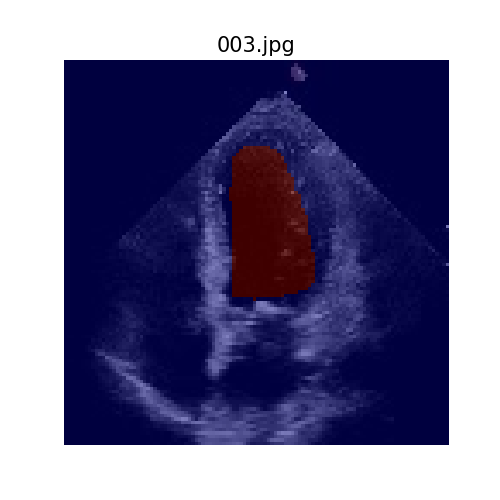

In [ ]:
demo = BboxPromptDemo("/content/Annotation Study", model)

##Run the following when you are done to download the data

In [ ]:
import zipfile
import os

# Define the paths
directory_to_zip = "/content/masks"
additional_file = "/content/all_bbox_data.json"
output_zip_path = "/content/masks_and_data.zip"

# Create a zip file
with zipfile.ZipFile(output_zip_path, 'w') as zipf:
    # Add the directory to the zip file
    for foldername, subfolders, filenames in os.walk(directory_to_zip):
        for filename in filenames:
            # Create the complete filepath of the file in the directory
            file_path = os.path.join(foldername, filename)
            # Add file to zip, preserving the folder structure
            zipf.write(file_path, os.path.relpath(file_path, directory_to_zip))

    # Add the additional JSON file to the zip
    zipf.write(additional_file, os.path.basename(additional_file))

print(f"Files from {directory_to_zip} and {additional_file} compressed into {output_zip_path}.")


Files from /content/masks and /content/all_bbox_data.json compressed into /content/masks_and_data.zip.


In [ ]:
from google.colab import files

# Download the zip file
files.download(output_zip_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>